In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')


from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.plot_results import plot_results_with_paths_3d, plot_saddle_tree_with_function, plot_full_connectivity_tree_style
from test_schwefel.schwefel_function_jax import Schwefel3D, schwefel_loss 

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
critical_points_file = "./critical_points_schwefel_3D.csv"

outdir = './results/'

dataframe = pd.read_csv(critical_points_file, index_col=0)
no_maxima = dataframe["type"]!="maximum"
dataframe = dataframe[no_maxima]

saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
# minima_df = dataframe[dataframe["type"] != "maximum"]

build_schwefel = lambda p: Schwefel3D(*p)

display(dataframe)

,x1,x2,x3,f_value,type
0,0.341809,0.824375,0.824375,0.217140,minimum
1,0.034551,0.034551,0.034551,1.066044,minimum
2,0.034551,0.034551,0.824375,0.710696,minimum
3,0.341809,0.341809,0.341809,0.651419,minimum
4,0.034551,0.824375,0.824375,0.355348,minimum
...,...,...,...,...,...
111,0.034551,0.166287,0.341809,1.114347,saddle
112,0.561167,0.034551,0.166287,1.616734,saddle
113,0.341809,0.034551,0.166287,1.114347,saddle
114,0.166287,0.824375,0.034551,0.897207,saddle


In [3]:
all_results, minima, dataframe, paths = trace_connectivity(saddles_df,
                                                           minima_df,
                                                           dataframe,
                                                           schwefel_loss,
                                                           build_schwefel,
                                                           [],
                                                           optimizer='gd',
                                                           log_paths=True)



Tracing saddle:  27
Offset 0: [0.56136153 0.34180944 0.56116652]
converged:  True
Offset 1: [0.56116656 0.34180944 0.56136149]
converged:  True
Offset 2: [0.5609716  0.34180944 0.56116652]
converged:  True
Offset 3: [0.56116656 0.34180944 0.56097156]
converged:  True

Tracing saddle:  28
Offset 0: [0.56136148 0.56116652 0.82437499]
converged:  True
Offset 1: [0.56116652 0.56136148 0.82437499]
converged:  True
Offset 2: [0.56097155 0.56116652 0.82437499]
converged:  True
Offset 3: [0.56116652 0.56097155 0.82437499]
converged:  True

Tracing saddle:  29
Offset 0: [0.16628746 0.16647893 0.03455081]
converged:  True
Offset 1: [0.16647893 0.16628746 0.03455081]
converged:  True
Offset 2: [0.16628746 0.16609599 0.03455081]
converged:  True
Offset 3: [0.16609599 0.16628746 0.03455081]
converged:  True

Tracing saddle:  30
Offset 0: [0.03455081 0.82437499 0.16647893]
converged:  True
Offset 1: [0.03455081 0.82437499 0.16609599]
converged:  True

Tracing saddle:  31
Offset 0: [0.82437499 0.341

In [ ]:
# save_descent_paths(paths, out_dir=outdir+'descent_paths/')

# build and save connectivity graph
connectivity_df = extract_connection_indices(all_results, dataframe)
output_file=f'{outdir}/connectivity_graph.csv'
connectivity_df.to_csv(output_file, index=False)

In [ ]:
# compute and save merge tree
from connectivity.merge_tree_calc import merge_tree
connectivity_file=f'{outdir}/connectivity_graph.csv'
connectivity_df = pd.read_csv(connectivity_file)
df_tree_nodes, df_tree_edges = merge_tree(dataframe, connectivity_df)
df_tree_nodes.to_csv(outdir+"tree_nodes.csv", index=False)
df_tree_edges.to_csv(outdir+"tree_connectivity.csv", index=False)
print(f"Saved tree to {outdir}")

Computing Join Tree...
Setting new_root index = 0
Saved tree to ./results/


/tmp/ipykernel_2766305/2148855689.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


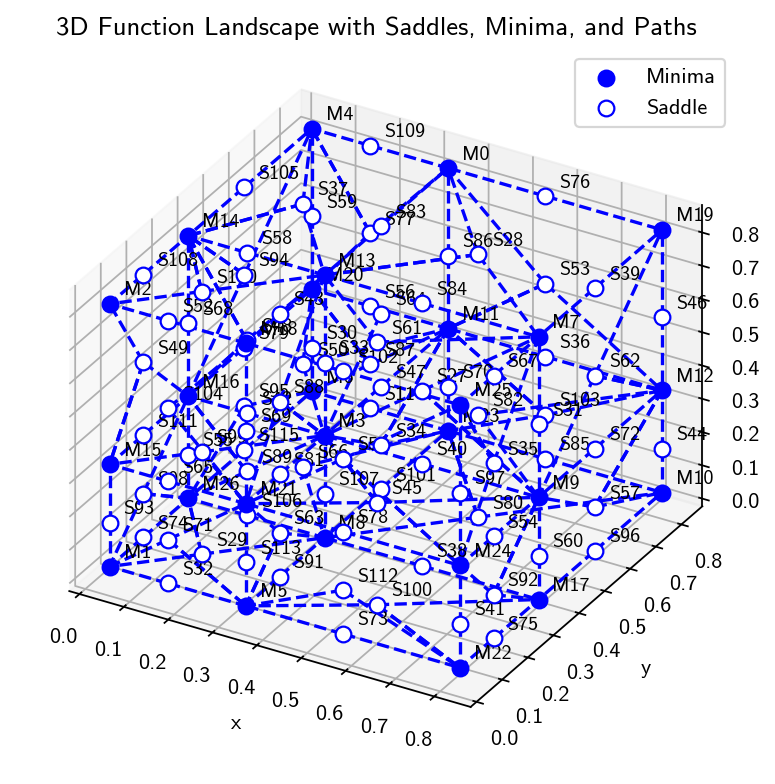

In [5]:
# visualise connectivity graph 
from schwefel_function_jax import _schwefel
schwefel3D_numpy = _schwefel

fig2 = plt.figure(figsize=(5,5), dpi=160)
fig2 = plot_results_with_paths_3d(func=schwefel3D_numpy,  
                                critical_points_csv=critical_points_file,
                                saddle_to_minima_csv="results/connectivity_graph.csv",      
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)

ax = fig2.axes[0]
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('3D Function Landscape with Saddles, Minima, and Paths')
ax.legend(loc='best')
fig2.tight_layout()

fig2.savefig(outdir+"/landscape_paths_3D.png")  # Optional
fig2.show()

/tmp/ipykernel_2775966/1550664320.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


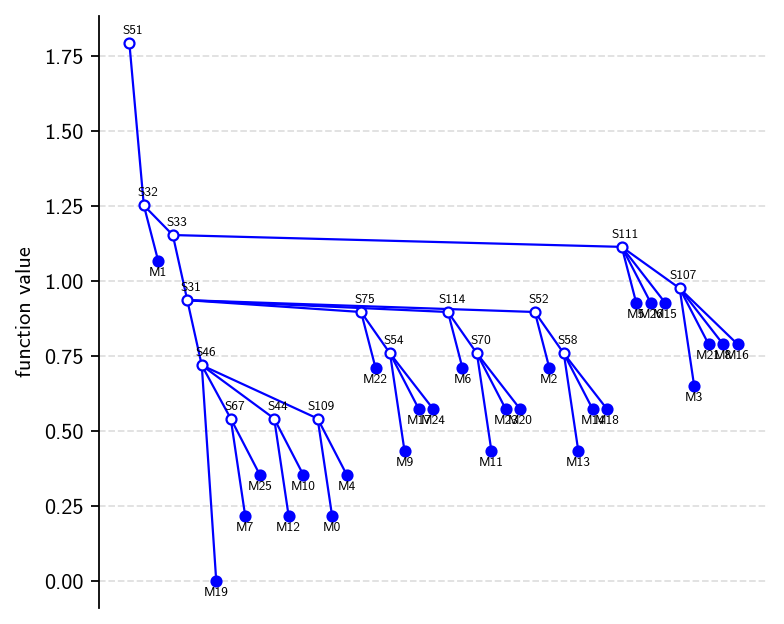

In [4]:
fig1 = plt.figure(figsize=(5, 4), dpi=160)
fig1 = plot_saddle_tree_with_function(dataframe, 
                                        nodes_csv="results/tree_nodes.csv",
                                        edges_csv="results/tree_connectivity.csv", 
                                        fig=fig1,
                                        markersize=20,
                                        fontsize=6,
                                        txt_pads=(5e-1, 4e-2))

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.savefig(outdir+"/tree_plot.png")  # Optional
fig1.show()